In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from matplotlib import ticker

from const import *

plt.style.use('default') # 重置
params = {
    'font.family': 'serif',        # 衬线体 (Times New Roman 等)
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'], # 显式指定
    'mathtext.fontset': 'stix',    # 数学公式字体更像 LaTeX
    'axes.labelsize': 14,
    'font.size': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.spines.top': False,      # 去掉顶部边框 (更简洁)
    'axes.spines.right': False,    # 去掉右侧边框
}
plt.rcParams.update(params)

In [13]:
from utilize.mesh_io import read_mshv2_triangular

node_pos_np, triangles = read_mshv2_triangular("../pd_stretch_tissue_mesh_init_2.msh")

v_min, v_max = -1.4, 0.6

First Exploration

In [8]:
Y_1 = np.loadtxt(f"Y_ekf-1.csv", delimiter=",")
low_value_1 = np.loadtxt(f"low_value_indices-1.csv", delimiter=",", dtype=int)

low_value_mask_1 = np.zeros(triangles.shape[0], dtype=bool)
low_value_mask_1[low_value_1] = True

V_1, F_1 = read_mshv2_triangular("pd_contact[3, 61]_step010.msh")

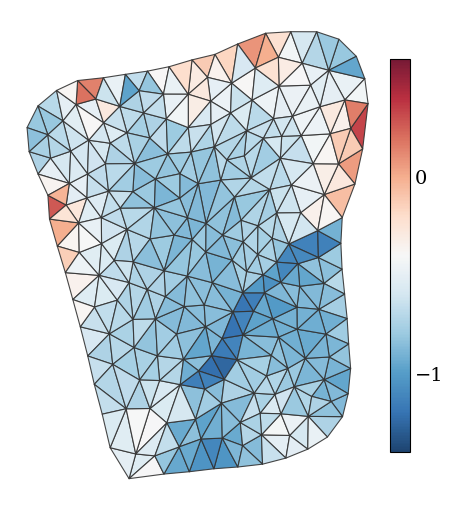

In [14]:
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

inform = np.log10(np.sqrt(np.diag(Y_1)))
# v_min, v_max = inform.min(), inform.max()
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im1 = ax1.tripcolor(V_1[:, 0], V_1[:, 1], F_1, 
                    facecolors=inform, shading='flat', 
                    edgecolors='#333333', linewidth=0.8, alpha=0.9, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.046)
cbar1.ax.tick_params(length=0, labelsize=14)
cbar1.locator = ticker.MultipleLocator(1)
cbar1.update_ticks()

plt.savefig(f"stiffness_inform-1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

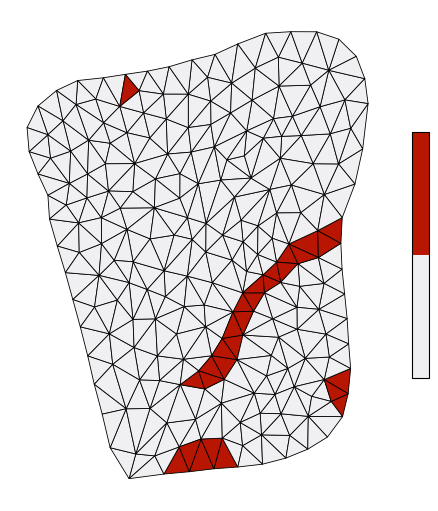

In [ ]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(V_1[:, 0], V_1[:, 1], F_1, 
                    facecolors=low_value_mask_1.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region-1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {low_value_mask_1.sum()} low-value elements out of {low_value_mask_1.size} total elements.")

[Local Evaluation] (Using GT band as reference)

  Band ROC-AUC: 0.9791

  Band PR-AUC: 0.9631

  Local Robust CNR: 1.7264

  Local FDR: 2.7171

[Global Evaluation]

  [Field Metric 1] ROC-AUC: 0.9891 (Closer to 1.0 is better)

  [Field Metric 2] PR-AUC: 0.9232 (Higher is better)

  [Field Metric 3] Robust CNR: 1.6319 (Higher is better)

  [Field Metric 4] FDR: 3.8698 (Higher is better)

[Global Segmentation Evaluation]

  [Seg Metric 1] Dice:       0.8085

  [Seg Metric 2] IoU:        0.6786

  [Seg Metric 3] Precision:  0.6786

  [Seg Metric 4] Recall:     1.0000

  [Seg Metric 5] Specificity:0.9734
  
  [Seg Metric 6] F1-score:   0.8085

Second Exploration

In [15]:
Y_2 = np.loadtxt(f"Y_ekf-2.csv", delimiter=",")
low_value_2 = np.loadtxt(f"low_value_indices-2.csv", delimiter=",", dtype=int)

low_value_mask_2 = np.zeros(triangles.shape[0], dtype=bool)
low_value_mask_2[low_value_2] = True

V_2, F_2 = read_mshv2_triangular("pd_contact[37, 95]_step010.msh")

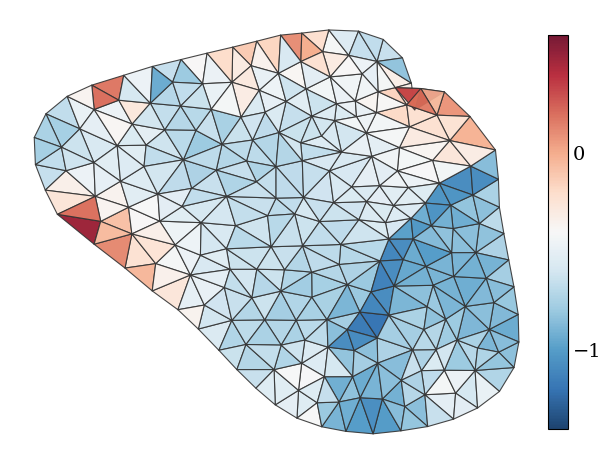

In [17]:
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

inform = np.log10(np.sqrt(np.diag(Y_2)))
# v_min, v_max = inform.min(), inform.max()
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im1 = ax1.tripcolor(V_2[:, 0], V_2[:, 1], F_2, 
                    facecolors=inform, shading='flat', 
                    edgecolors='#333333', linewidth=0.8, alpha=0.9, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.046)
cbar1.ax.tick_params(length=0, labelsize=14)
cbar1.locator = ticker.MultipleLocator(1)
cbar1.update_ticks()

plt.savefig(f"stiffness_inform-2.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

In [18]:
inform.min()

-1.1927447454539257

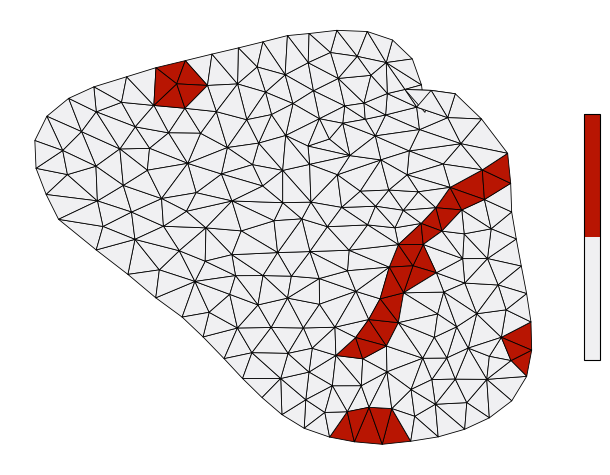

In [17]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(V_2[:, 0], V_2[:, 1], F_2, 
                    facecolors=low_value_mask_2.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region-2.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

[Local Evaluation] (Using GT band as reference)

  Band ROC-AUC: 0.9721

  Band PR-AUC: 0.9527

  Local Robust CNR: 1.2244

  Local FDR: 2.4481

[Global Evaluation]

  [Field Metric 1] ROC-AUC: 0.9863 (Closer to 1.0 is better)

  [Field Metric 2] PR-AUC: 0.8904 (Higher is better)

  [Field Metric 3] Robust CNR: 1.7211 (Higher is better)

  [Field Metric 4] FDR: 3.9485 (Higher is better)

[Global Segmentation Evaluation]

  [Seg Metric 1] Dice:       0.7170

  [Seg Metric 2] IoU:        0.5588

  [Seg Metric 3] Precision:  0.5588

  [Seg Metric 4] Recall:     1.0000

  [Seg Metric 5] Specificity:0.9556
  
  [Seg Metric 6] F1-score:   0.7170